# LangGraph - Lesson 1

## What is LangGraph?

LangGraph is a framework for building stateful, multi-step AI workflows.

Unlike a simple chain, LangGraph allows:
- State management
- Loops
- Conditional routing
- Multiple agents
- Reflection workflows

Everything in LangGraph revolves around:

- State
- Nodes
- Edges

| Element     | Vazifasi                 |
| ----------- | ------------------------ |
| State       | Ma'lumotlarni saqlaydi   |
| Node        | Ish bajaradigan function |
| Edge        | Node'larni bog'laydi     |
| Graph       | Workflow                 |
| START / END | Boshlanish va tugash     |


In [1]:
from typing import TypedDict

from langgraph.graph import StateGraph
from langgraph.graph import START, END

In [3]:
class State(TypedDict):
    message: str

In [4]:
def hello_node(state: State):
    state['message'] = 'Hello LangGraph'
    return state

In [5]:
graph = StateGraph(State)

In [6]:
graph.add_node('hello', hello_node)

In [7]:
graph.add_edge(START, 'hello')

In [8]:
graph.add_edge('hello', END)

In [9]:
app = graph.compile()

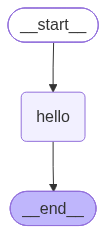

In [10]:
app

In [11]:
result = app.invoke({
    'message': ''
})

print(result)

{'message': 'Hello LangGraph'}


```
1. State yaratamiz
        ↓
2. StateGraph(State)
        ↓
3. Node larni yozamiz (function)
        ↓
4. graph.add_node()
        ↓
5. graph.add_edge() yoki graph.add_conditional_edges()
        ↓
6. graph.compile()
        ↓
7. app.invoke(initial_state)
        ↓
8. LangGraph node larni ketma-ket bajaradi
        ↓
9. Yakuniy State qaytadi
```

-----

```
State
   ↓
Node
   ↓
State
   ↓
Node
   ↓
State
   ↓
Node
   ↓
END
```

## **Step 2**

In [12]:
class State(TypedDict):
    message: str
    decision: str

In [13]:
def writer_node(state: State):
    state['message'] = 'Hello LangGraph'
    return state

In [14]:
def checker_node(state: State):
    if state['message']:
        state['decision'] = 'Pass'
    else:
        state['decision'] = 'Fail'
        
    return state

In [15]:
def router(state: State):
    return state['decision']

In [16]:
graph = StateGraph(State)

graph.add_node('writer', writer_node)
graph.add_node('checker', checker_node)

graph.add_edge(START, 'writer')
graph.add_edge('writer', 'checker')

In [17]:
graph.add_conditional_edges(
    'checker',
    router,
    {
        'Pass': END,
        'Fail': 'writer'
    }
)

In [18]:
app = graph.compile()

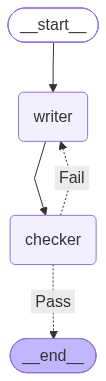

In [19]:
app

In [20]:
results = app.invoke({
    'message': ''
})

In [21]:
results

{'message': 'Hello LangGraph', 'decision': 'Pass'}